# Squat 2D → 3D demo

Run a single still image through the project's pose stack:

1. Load image
2. RTMPose (via `Pose2D`) → 17 COCO-2D keypoints + skeleton overlay
3. MotionBERT-Lite (via `Pose3D`) → 17 H36M-3D keypoints, rendered as a rotatable matplotlib figure

For the rotatable 3D plot, you need the `ipympl` widget backend:

```bash
uv add --dev jupyter ipympl
```

Then start the kernel with `uv run jupyter lab` and select this notebook.


In [1]:
import sys
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Point this at your own squat image. PNG/JPG, person fully visible.
IMAGE_PATH = PROJECT_ROOT / "notebooks" / "data" / "squat.jpg"
assert IMAGE_PATH.exists(), f"missing image: {IMAGE_PATH}"

Matplotlib is building the font cache; this may take a moment.


## 1. Load and display the image


image: 1300x956


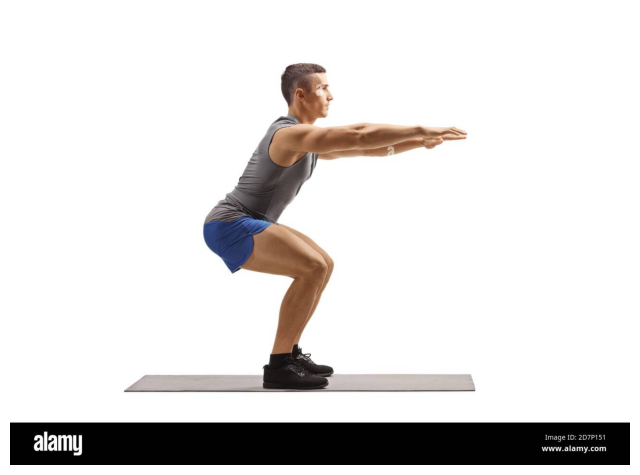

In [2]:
%matplotlib inline

frame_bgr = cv2.imread(str(IMAGE_PATH))
assert frame_bgr is not None, "cv2.imread returned None"
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
H, W = frame_bgr.shape[:2]
print(f"image: {W}x{H}")

plt.figure(figsize=(8, 6))
plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

## 2. 2D pose with RTMPose

Uses the project's `Pose2D` wrapper (YOLOX-tiny + RTMPose-s, ONNX/CPU). Returns 17 COCO-format keypoints + per-joint confidences.


In [3]:
from pose2d import Pose2D
from render import SKELETON  # COCO-17 bones

pose2d = Pose2D(device="cpu", mode="lightweight")
kps_2d, scores = pose2d.infer(frame_bgr)
print("kps:", kps_2d.shape, "scores:", scores.shape)
print("mean score:", float(scores.mean()))

load /Users/thatt/Dev/AI project/new-workout-ai/models/rtmlib_cache/hub/checkpoints/yolox_tiny_8xb8-300e_humanart-6f3252f9.onnx with onnxruntime backend
load /Users/thatt/Dev/AI project/new-workout-ai/models/rtmlib_cache/hub/checkpoints/rtmpose-s_simcc-body7_pt-body7_420e-256x192-acd4a1ef_20230504.onnx with onnxruntime backend
kps: (17, 2) scores: (17,)
mean score: 0.7761130332946777


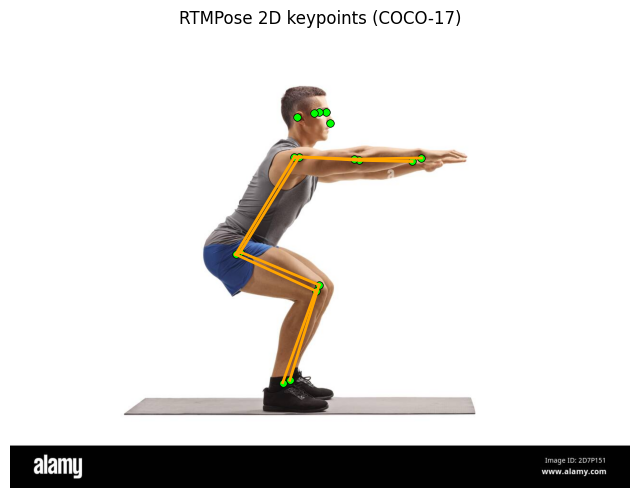

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(frame_rgb)

THRESH = 0.3
for a, b in SKELETON:
    if scores[a] < THRESH or scores[b] < THRESH:
        continue
    ax.plot(
        [kps_2d[a, 0], kps_2d[b, 0]],
        [kps_2d[a, 1], kps_2d[b, 1]],
        color="orange",
        linewidth=2,
    )

visible = scores >= THRESH
ax.scatter(
    kps_2d[visible, 0],
    kps_2d[visible, 1],
    s=30,
    c="lime",
    edgecolors="black",
    linewidths=0.5,
)
ax.set_title("RTMPose 2D keypoints (COCO-17)")
ax.axis("off")
plt.show()

## 3. Lift to 3D with MotionBERT-Lite

MotionBERT expects a temporal window of 27 frames in H36M-17 layout. For a still image we tile the same pose across the window — fine for a one-shot demo, though obviously the model can't infer any motion-dependent depth cues.


In [5]:
from pose3d import Pose3D, coco17_to_h36m17

pose3d = Pose3D()  # auto-selects MPS on Apple Silicon

h36m = coco17_to_h36m17(kps_2d, scores)  # (17, 3) [x, y, score]
window = np.stack([h36m] * pose3d.window_size, axis=0)  # (27, 17, 3)
kps_3d = pose3d.infer(window, frame_h=H, frame_w=W)  # (17, 3)
print("3D kps shape:", kps_3d.shape)
print("range x:", kps_3d[:, 0].min(), kps_3d[:, 0].max())
print("range y:", kps_3d[:, 1].min(), kps_3d[:, 1].max())
print("range z:", kps_3d[:, 2].min(), kps_3d[:, 2].max())

3D kps shape: (17, 3)
range x: -0.2726632 0.315698
range y: -0.44691777 0.39594305
range z: -0.19019298 0.15328301


## 4. Rotatable 3D plot

Switches to the `ipympl` backend so the figure becomes a draggable widget. Click-and-drag to orbit, scroll to zoom.

Axis convention used here: MotionBERT emits coords with image-style y pointing down, so we flip it to render the person upright. Bones use the H36M-17 topology (different from the COCO skeleton used in 2D).


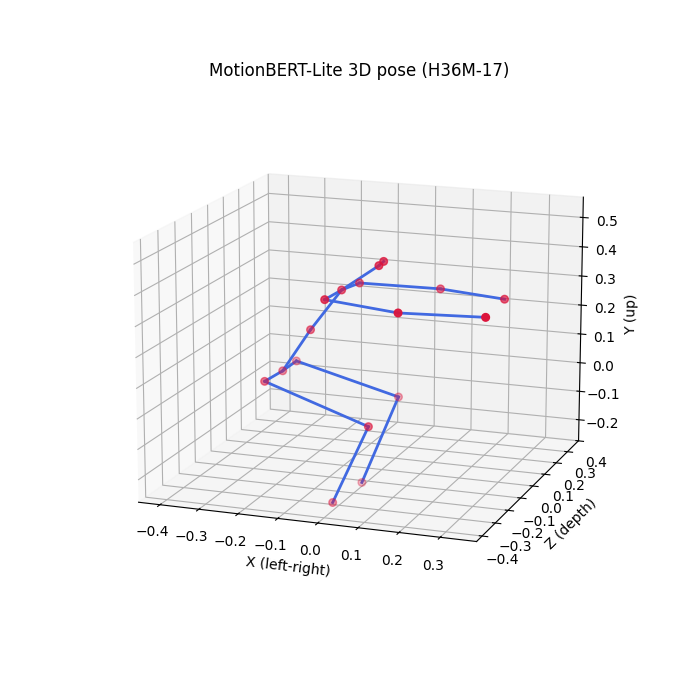

In [6]:
%matplotlib widget

# H36M-17 bones (pelvis-rooted).
H36M_SKELETON = [
    (0, 1),
    (1, 2),
    (2, 3),  # right leg
    (0, 4),
    (4, 5),
    (5, 6),  # left leg
    (0, 7),
    (7, 8),
    (8, 9),
    (9, 10),  # spine + head
    (8, 11),
    (11, 12),
    (12, 13),  # left arm
    (8, 14),
    (14, 15),
    (15, 16),  # right arm
]

X = kps_3d[:, 0]
Y = kps_3d[:, 2]  # depth → matplotlib Y
Z = -kps_3d[:, 1]  # flip image-down to up

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

for a, b in H36M_SKELETON:
    ax.plot([X[a], X[b]], [Y[a], Y[b]], [Z[a], Z[b]], color="royalblue", linewidth=2)
ax.scatter(X, Y, Z, c="crimson", s=30)

# Equal-aspect cube so the figure isn't squashed.
max_range = np.array([np.ptp(X), np.ptp(Y), np.ptp(Z)]).max() / 2.0
mid = [X.mean(), Y.mean(), Z.mean()]
ax.set_xlim(mid[0] - max_range, mid[0] + max_range)
ax.set_ylim(mid[1] - max_range, mid[1] + max_range)
ax.set_zlim(mid[2] - max_range, mid[2] + max_range)

ax.set_xlabel("X (left-right)")
ax.set_ylabel("Z (depth)")
ax.set_zlabel("Y (up)")
ax.view_init(elev=15, azim=-70)
ax.set_title("MotionBERT-Lite 3D pose (H36M-17)")
plt.show()

## 5. Joint angles from the 3D pose

For each interior joint, compute the angle between the incoming bone (from its parent) and the outgoing bone (to its child) — i.e. how "bent" the joint is. 180° = fully extended (straight line), 0° = folded onto itself.

Endpoints (pelvis, ankles, wrists, head) have no angle. The H36M head/neck joints are synthesized from a single COCO nose keypoint, so the neck angle is degenerate and reported as `nan`.


In [ ]:
H36M_NAMES = [
    "pelvis",
    "R_hip",
    "R_knee",
    "R_ankle",
    "L_hip",
    "L_knee",
    "L_ankle",
    "spine",
    "thorax",
    "neck",
    "head",
    "L_shoulder",
    "L_elbow",
    "L_wrist",
    "R_shoulder",
    "R_elbow",
    "R_wrist",
]

JOINT_TRIPLES = [
    (0, 1, 2),  # R hip
    (1, 2, 3),  # R knee
    (0, 4, 5),  # L hip
    (4, 5, 6),  # L knee
    (0, 7, 8),  # spine (pelvis -> spine -> thorax)
    (7, 8, 9),  # thorax (toward neck)
    (8, 9, 10),  # neck (degenerate: neck==head from a single nose kpt)
    (8, 11, 12),  # L shoulder
    (11, 12, 13),  # L elbow
    (8, 14, 15),  # R shoulder
    (14, 15, 16),  # R elbow
]


def joint_angle_deg(p, j, c, eps=1e-6):
    """Angle in degrees at joint `j` between bones j->p and j->c. nan if degenerate."""
    v1 = p - j
    v2 = c - j
    n1 = np.linalg.norm(v1)
    n2 = np.linalg.norm(v2)
    if n1 < eps or n2 < eps:
        return float("nan")
    cos = np.clip(np.dot(v1, v2) / (n1 * n2), -1.0, 1.0)
    return float(np.degrees(np.arccos(cos)))


print(f"{'joint':<12} {'angle (deg)':>12}")
print("-" * 26)
for p, j, c in JOINT_TRIPLES:
    ang = joint_angle_deg(kps_3d[p], kps_3d[j], kps_3d[c])
    print(f"{H36M_NAMES[j]:<12} {ang:>12.1f}")

joint         angle (deg)
--------------------------
R_hip                80.3
R_knee               95.7
L_hip               104.1
L_knee               97.5
spine               175.7
thorax              163.6
neck                107.6
L_shoulder          114.5
L_elbow             156.2
R_shoulder           98.4
R_elbow             160.5


## 6. Score the rep with the project's rule engine

Wrap the arrays we already have into a `PoseFrame` and call `analysis.rules_squat.score_rep`. This is the same function that the live FSM uses when a rep completes at the bottom of the squat.

Tempo (`descent_ms`/`ascent_ms`) is **stubbed** here because a single still has no temporal context — the FSM normally measures these from frame timestamps. Picking `descent_ms >= ascent_ms` keeps the tempo component full (10/10) so the score reflects only posture, not a fake tempo.


In [8]:
import time

from analysis.types import PoseFrame
from analysis.rules_squat import score_rep

# Per-component max points (see src/analysis/rules_squat.py).
COMPONENT_MAX = {"depth": 30, "valgus": 25, "torso": 20, "symmetry": 15, "tempo": 10}

frame = PoseFrame(
    timestamp=time.time(),
    keypoints_2d=kps_2d,
    scores=scores,
    frame_shape=(H, W),
    keypoints_3d=kps_3d,
)

rep = score_rep(frame, descent_ms=2000, ascent_ms=1500, rep_index=0)

print(f"score: {rep.score}/100")
print("components:")
for name, pts in rep.components.items():
    print(f"  {name:<10} {pts:>3}/{COMPONENT_MAX[name]}")
print(f"violations ({len(rep.violations)}):")
for v in rep.violations:
    print(f"  - {v.name} (sev {v.severity:.2f}): {v.detail_th}")

score: 92/100
components:
  depth       25/30
  valgus      22/25
  torso       20/20
  symmetry    15/15
  tempo       10/10
violations (2):
  - shallow_depth (sev 0.16): ยังลงไม่ลึกพอ ลองงอเข่าให้สะโพกต่ำกว่าหัวเข่า
  - knee_valgus (sev 0.11): หัวเข่าเข้าด้านใน ควรกางหัวเข่าออกตามแนวปลายเท้า


## 7. Thai coaching text from on-device LLM (Qwen3.5-4B mxfp4)

`ThaiCoachLLM` wraps Qwen3.5-4B via `mlx-vlm`. The **first** call after loading triggers MLX compilation and takes ~10–30 s on Apple Silicon — `warmup()` exists exactly so the cost is paid before the real `generate()`.

We pass an explicit `model_dir` because `feedback/llm.py`'s default resolves one directory above the project root (a known wrinkle worth fixing later; for the demo we just pin the path).


In [9]:
from feedback.llm import ThaiCoachLLM

QWEN_DIR = PROJECT_ROOT / "models" / "qwen3_5_4b_mxfp4"
assert QWEN_DIR.exists(), (
    f"missing Qwen weights: {QWEN_DIR} — run scripts/download_models.py"
)

t0 = time.time()
coach = ThaiCoachLLM(model_dir=QWEN_DIR)
print(f"loaded in {time.time() - t0:.1f}s")

t0 = time.time()
coach.warmup()
print(f"warmup in {time.time() - t0:.1f}s")

t0 = time.time()
coach_text = coach.generate(rep)
print(f"generated in {time.time() - t0:.1f}s\n")
print(coach_text)

loaded in 3.3s
warmup in 0.2s
generated in 0.3s

คุณทำได้ดีมากในจังหวะการเคลื่อนไหวและการทรงตัวที่สมมาตร แต่ควรปรับโดยกางเข่าให้กว้างขึ้นและลงลึกจนสะโพกต่ำกว่าหัวเข่าเพื่อประสิทธิภาพที่ดีขึ้น


## 8. Speak the feedback — Gemini TTS

Same call pattern as `scripts/test_sound.py`: Gemini 2.5 Flash TTS with the `Charon` prebuilt voice, 24 kHz mono PCM written into a WAV container. Reads the API key from `.env` under the (lowercase) name `google_ai_studio_api_key`, matching the existing script.


In [10]:
import os
import wave

from dotenv import load_dotenv
from google import genai
from google.genai import types

load_dotenv(PROJECT_ROOT / ".env")
tts_client = genai.Client(api_key=os.environ["google_ai_studio_api_key"])

tts_script = f"ผลการประเมินท่าสควอตของคุณ {coach_text}"
print(f"--- coach_text ({len(coach_text)} chars) ---")
print(repr(coach_text))
print(f"--- tts_script ({len(tts_script)} chars) ---")
print(repr(tts_script[:400]))

t0 = time.time()
tts_response = tts_client.models.generate_content(
    model="gemini-2.5-flash-preview-tts",
    contents=tts_script,
    config=types.GenerateContentConfig(
        response_modalities=["AUDIO"],
        speech_config=types.SpeechConfig(
            voice_config=types.VoiceConfig(
                prebuilt_voice_config=types.PrebuiltVoiceConfig(voice_name="Charon")
            )
        ),
    ),
)
print(f"\nTTS call returned in {time.time() - t0:.1f}s")

# --- Defensive unpacking with diagnostics ---
print("prompt_feedback:", getattr(tts_response, "prompt_feedback", None))
if not tts_response.candidates:
    raise RuntimeError("TTS returned no candidates")

cand = tts_response.candidates[0]
print("finish_reason:", getattr(cand, "finish_reason", None))
print("safety_ratings:", getattr(cand, "safety_ratings", None))

if cand.content is None or not getattr(cand.content, "parts", None):
    raise RuntimeError(
        f"TTS produced no audio content. finish_reason={getattr(cand, 'finish_reason', None)}. "
        f"See prints above for the input that was sent."
    )

part = cand.content.parts[0]
if part.inline_data is None:
    raise RuntimeError(f"TTS part has no inline_data. Part: {part}")

pcm = part.inline_data.data
wav_path = PROJECT_ROOT / "notebooks" / "data" / "squat_coach.wav"
wav_path.parent.mkdir(parents=True, exist_ok=True)
with wave.open(str(wav_path), "wb") as wf:
    wf.setnchannels(1)
    wf.setsampwidth(2)
    wf.setframerate(24000)
    wf.writeframes(pcm)
print(f"\nwrote {len(pcm)} bytes of PCM → {wav_path}")

--- coach_text (142 chars) ---
'คุณทำได้ดีมากในจังหวะการเคลื่อนไหวและการทรงตัวที่สมมาตร แต่ควรปรับโดยกางเข่าให้กว้างขึ้นและลงลึกจนสะโพกต่ำกว่าหัวเข่าเพื่อประสิทธิภาพที่ดีขึ้น'
--- tts_script (169 chars) ---
'ผลการประเมินท่าสควอตของคุณ คุณทำได้ดีมากในจังหวะการเคลื่อนไหวและการทรงตัวที่สมมาตร แต่ควรปรับโดยกางเข่าให้กว้างขึ้นและลงลึกจนสะโพกต่ำกว่าหัวเข่าเพื่อประสิทธิภาพที่ดีขึ้น'

TTS call returned in 9.0s
prompt_feedback: None
finish_reason: FinishReason.STOP
safety_ratings: None

wrote 628366 bytes of PCM → /Users/thatt/Dev/AI project/new-workout-ai/notebooks/data/squat_coach.wav


## 9. Play the result inline


In [11]:
from IPython.display import Audio

Audio(str(wav_path), autoplay=False)